In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from datetime import date
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms

import copy
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.express as px
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm



In [20]:



def save_my_work(model, logfile, opt, Bsize, learningRate, epoch, second_time, best_mse, mse, loss, init_time, model_file_name):
    #model_save_time = str(int(time.time()))
    model_save_time = str(int(second_time))
    # model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + model_save_time + '.pt'
    # model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + str(int(second_time)) + '_RMSE_' + str( ((mse**(1/2))//0.0001)*0.0001 ) + '.pt'
    elapsed_time = (time.time()-second_time)/60
    
    print('start to save model')
    torch.save(model, model_file_name )
    
    print('start to save log')
    print(
                    model_file_name,
                    # 'data:', xdata_name,
                    file=logfile
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    file=logfile
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % ( best_mse**(1/2) ),
                ', RMSE_Test: %5f' % (mse**(1/2)),
                ', RMSE_Train: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                file=logfile
                )


    print(
                    model_file_name,
                    # 'data:', xdata_name,
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % (best_mse**(1/2)),
                ', test_loss: %5f' % (mse**(1/2)),
                ', train_loss: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                )
    print('start to save figures')

    fig, axs = plt.subplots(2, 1, figsize=(5, 5*2))#, sharey=True)
    axs[0].set_xlabel('Epoch', fontsize=10)
    axs[0].set_ylabel(r'Test Loss', fontsize=10)
    axs[0].legend()
    axs[0].plot(history, )
    axs[0].set_yscale('log')
    axs[0].set_title('Test_Loss')
    axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str((elapsed_time//0.001) * 0.001  ))


    axs[1].set_xlabel('Epoch', fontsize=10)
    axs[1].set_ylabel(r'Train Loss', fontsize=10)
    axs[1].legend()
    axs[1].plot(history_train)
    axs[1].set_yscale('log')
    axs[1].set_title('Train_Loss')

    # fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
    # fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

    # plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

    plt.savefig(
                model_file_name[0:-3] + 'Loss' + '.pdf',
                format="pdf",
                bbox_inches="tight"
                )
    plt.show()
    print('saving work is done')



In [9]:
def print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time):
    print(

        'act: ', act ,
        'opt: ', opt ,
        'batch_size: ', batch_size ,
        'learningRate: ', learningRate ,
        'epoch: %5d' % epoch,
        ', RMSE_Test: {:7.5f}'.format(mse**(1/2)),
        ', RMSE_Train: {:7.5f}'.format(loss**(1/2)),
        ', est_time: {:5.1f}'.format(( ( ( time.time()-second_time ) )  / 60  )),  'min,',
        'average_time: {:.2f}'.format( ( time.time()-second_time )/(epoch+1)), 's'
        )

In [4]:
X_train = torch.load('X_train'+'.pt' )
y_train = torch.load('y_train'+'.pt' )
X_test = torch.load('X_test'+'.pt' )
y_test = torch.load('y_test'+'.pt' )

In [5]:
X_train

tensor([[1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000],
        [1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000],
        [1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000],
        ...,
        [1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000],
        [1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000],
        [1.0000, 1.0080, 1.0000,  ..., 2.0000, 6.5000, 0.0000]])

In [ ]:

#default

"""

"""
# for learningRate in range(10): #


# dim_list = [2, 100, 100, 100, 10, 1] 10 min: 0.03 loss
dim_list = [2200, 100, 100, 10, 1]


f = open("mylog.txt", "a")
#If data is less complex and is having fewer dimensions or features then neural networks with 1 to 2 hidden layers would work.
# If data is having large dimensions or features then to get an optimum solution, 3 to 5 hidden layers can be used.

init_time = time.time()
best_record = ''
best_mse = np.inf   # init to infinity
best_weights = None
print('start')

for act in [
            # 'LeakyReLU',
            # 'LogSigmoid',
            # 'Softplus'
            'ReLU'
            ]:

    for opt in [
                # 'Adadelta',
                # 'Adagrad',
                'Adam',
                # 'AdamW',
                # 'SparseAdam',
                # 'Adamax',
                # 'ASGD',
                # 'LBFGS',
                # 'NAdam',
                # 'RAdam',
                # 'RMSprop',
                # 'Rprop',
                # 'SGD'
                ]:

        # for batch_size in [ 8, 16, 32, 64, 128]:
        # for Bsize in [ 10, 100, 1000]:
        for batch_size in [ 8 ]:

            # for learningRate in [ 1e-1, 1e-2, 1e-3, 1e-4,1e-5, 1e-6, ]:
            # for learningRate in [ 1e-1, 5e-1, 1e-2, 5e-2, 1e-3, 5e-3, 1e-4, 5e-4, 1e-5, 5e-5, 1e-6, 5e-6, ]:
            for learningRate in [  0.01 ]:
                # try:
                    make_model = 'model = nn.Sequential('
                    for layer_num in range( len(dim_list) - 1 ):
                        if layer_num == len(dim_list) - 2:
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']) )'
                        else:
                            # make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.LeakyReLU(),'
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.' + act + '(),'


                    exec(make_model)

                    exec('optimizer = optim.' + opt + '(model.parameters(), lr=learningRate  )')

                    batch_start = torch.arange(0, len(X_train), batch_size)

                    # Hold the best model

                    history = []
                    history_train = []


                    # for epoch in range(n_epochs):
                    second_time = time.time()

                    epoch = 0
                    len_batch = len(X_train)
                    loss_func = nn.MSELoss()
                    while(1):

                        model.train()

                        for start in range(0,len_batch, batch_size):

                            X_batch = X_train[start:start+batch_size] # 두번째 값이 길이를 초과해도 오류안뜨고 그냥 시작부터 끝까지 출력해주는 착한친구.
                            y_batch = y_train[start:start+batch_size]
                            # forward pass
                            y_pred = model(X_batch).squeeze()

                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2 + (y_pred-y_batch)**2 )
                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2  )

                            # loss = before_loss**(1/2)
                            loss = loss_func(y_pred,y_batch )

                            # backward pass
                            optimizer.zero_grad()
                            loss.backward()

                            # update weights
                            optimizer.step()

                        loss = float(loss)

                        history_train.append(loss)

                        model.eval()
                        y_pred = model(X_test).squeeze()
                        #print(y_pred)

                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2 + (y_pred-y_test)**2 )
                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2   )

                        # mse = before_loss**(1/2)
                        mse = loss_func(y_pred, y_test)

                        mse = float(mse)

                        history.append(mse)
                        
                        if best_mse<1:
                            model_file_name = 'my_results/'+'model_' + str(int(second_time)) + '_best_' + str( best_mse**(1/2) )[:4] + '.pt'
                        elif best_mse==np.inf:
                            pass
                        else:
                            model_file_name = 'my_results/'+'model_' + str(int(second_time)) + '_best_' + str( int(best_mse**(1/2)) ) + '.pt'

                        if mse < best_mse:
                            best_mse = mse
                            # best_weights = copy.deepcopy(model.state_dict())
                            
                            torch.save(model, model_file_name )
                            best_record =  (
                                            model_file_name,

                                            ', layer_dim_list:', dim_list,
                                            'activateion:', act,
                                            ', optimizer:', opt,
                                            ', Bsize:', batch_size ,
                                            ', learningRate:', learningRate ,

                                            ', epoch: %5d' % epoch,
                                            ', passed_time: %.3f' % ( ( time.time()-second_time )  / 60  ),  'm',

                                            ", minimum_RMSE: %.5f" % (best_mse**(1/2)),
                                            ', test_loss: %5f' % (mse),
                                            ', train_loss: %5f' % (loss),
                                            ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',

                                            )

                        if epoch % 1000 == 0:
                        # if ( time.time()-second_time )  / 60 == 0:
                            # print('epoch: %5d' % epoch, 'test_loss: %.2f' % (mse), 'train_loss: %.2f' % (loss), 'est_time: %.2f' % (( ( epoch_time ) / (epoch+1) ) / 60 * (n_epochs-epoch) ) ,'min', "epoch_time:", epoch_time, 's')
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            # print('{:.6}'.format(val))
                            # print("{:10.4f}".format(x))

                        # if (mse<10) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 0.1  ):
                        # if (mse**(1/2) < 0.005) or (str(mse)=='nan'): # 1~10 까지의 값 중에서  E 의 최솟값은 0.05이다. 그런데 이 값의 1퍼센트 오차인
                        # if (mse**(1/2) < 0.1) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 1 ):
                        if (mse**(1/2) < 0.1) or (str(mse)=='nan') :
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            save_my_work(model, f, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time, 'final_'+model_file_name)
                            break
                        epoch = epoch + 1

                    # restore model and return best accuracy
                    # model.load_state_dict(best_weights)
                    # print("MSE: %.2f" % best_mse)
                    # print("RMSE: %.2f" % np.sqrt(best_mse))


                    print('finish--------------------------------------------------------------------------------------------------------------------------------------------------------')
                    print('')

                # except:
                #     # os.mkdir('/content/drive/MyDrive/0_318lab/SCMP_ML/')
                #     print('error has occured')
                #     save_my_work(model, f, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time, 'error_'+model_file_name)

f.close()
print('These parameters showed the best performance!--------------------------------------------------------------------------------')
print(best_record)
print('all done')
# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
'''
comment

'''


start
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:     0 , RMSE_Test: 2.32455 , RMSE_Train: 2.22054 , est_time:   0.0 min, average_time: 0.04 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:  1000 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   0.4 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:  2000 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   0.7 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:  3000 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   1.1 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:  4000 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   1.5 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:  5000 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   2.1 min, average_time: 0.03 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


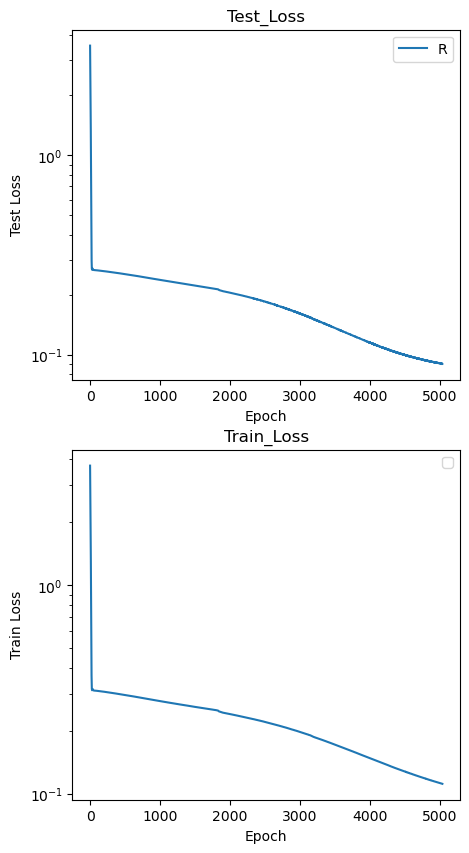

In [15]:
# learningRate : -3,-4
fig, axs = plt.subplots(2, 1, figsize=(5, 5*2))#, sharey=True)
axs[0].set_xlabel('Epoch', fontsize=10)
axs[0].set_ylabel(r'Test Loss', fontsize=10)
axs[0].legend()
axs[0].plot(history, )
axs[0].set_yscale('log')
axs[0].set_title('Test_Loss')
axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(batch_size)+"_"+ str(learningRate))


axs[1].set_xlabel('Epoch', fontsize=10)
axs[1].set_ylabel(r'Train Loss', fontsize=10)
axs[1].legend()
axs[1].plot(history_train)
axs[1].set_yscale('log')
axs[1].set_title('Train_Loss')

# fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
# fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

# plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

plt.show()